## Full plot generation pass
Add you plot implementations here when they are complete so that as we update and finish the second pass new sets of plots can be immediatly generated. Comment appropriatly and describe what the plot is showing.

In [ ]:
import re
from pathlib import Path
import importlib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from plotting_scripts.FAIR_compliance import (
    F,
    A,
    I,
    R,
    Letter_compliance,
    calculate_all_letter_compliance_rates,
    calculate_criterion_compliance_rates,
    calculate_full_fair_compliance,
    print_fair_summary,
)
from processing_scripts.pre_process import scleaned_pandas
from plotting_scripts.repository_stats import repo_stats_main
import plotting_scripts.fair_letter_compliance as fair_letter_compliance

importlib.reload(fair_letter_compliance)

# Load first-pass data
sample_file = "results/FAIR Evaluation Results - First Pass Responses_fixed.csv"
drop_cols = [
    "A1 follow-up: Which of these protocols are available to download the software?",
    "R2 follow-up: Is there a file / project manager tool to help with the installation of other software / libraries?",
    "Is the software itself documented well?",
    "Which of the following code readability standards have been implemented?",
    "How long did this form take to complete?",
    "Anything else to note?",
    "Any additional notes for F?",
    "Any additional notes for A?",
    "Any additional notes for I?",
    "Any additional notes for R?",
]

available_cols = pd.read_csv(sample_file, nrows=0).columns
columns_to_drop = [col for col in drop_cols if col in available_cols]

df = scleaned_pandas(
    sample_file,
    columns_to_drop=columns_to_drop,
    index_col="Paper Name:",
)

artifact_col = "Are any software artefacts/tools/scripts mentioned in and used in the process of gathering results for the report?"
if artifact_col not in df.columns:
    raise ValueError(f"Missing expected column: {artifact_col}")

df = df[df[artifact_col].astype(str).str.strip().str.lower() == "yes"]

# Load second-pass data
second_sample_file = "results/FAIR Evaluation Results - Second Pass Responses_fixed.csv"
second_available_cols = pd.read_csv(second_sample_file, nrows=0).columns
second_columns_to_drop = [col for col in drop_cols if col in second_available_cols]

df_second = scleaned_pandas(
    second_sample_file,
    columns_to_drop=second_columns_to_drop,
    index_col="Paper Name:",
)

if artifact_col not in df_second.columns:
    raise ValueError(f"Missing expected column: {artifact_col}")

df_second = df_second[df_second[artifact_col].astype(str).str.strip().str.lower() == "yes"]

# Plot full FAIR compliance by letter for both passes
fair_letter_compliance.plot_fair_letter_compliance(df, df_second)

TypeError: plot_fair_letter_compliance() takes 1 positional argument but 2 were given

Saved plot to graphs\fair_criterion_compliance_by_letter.png


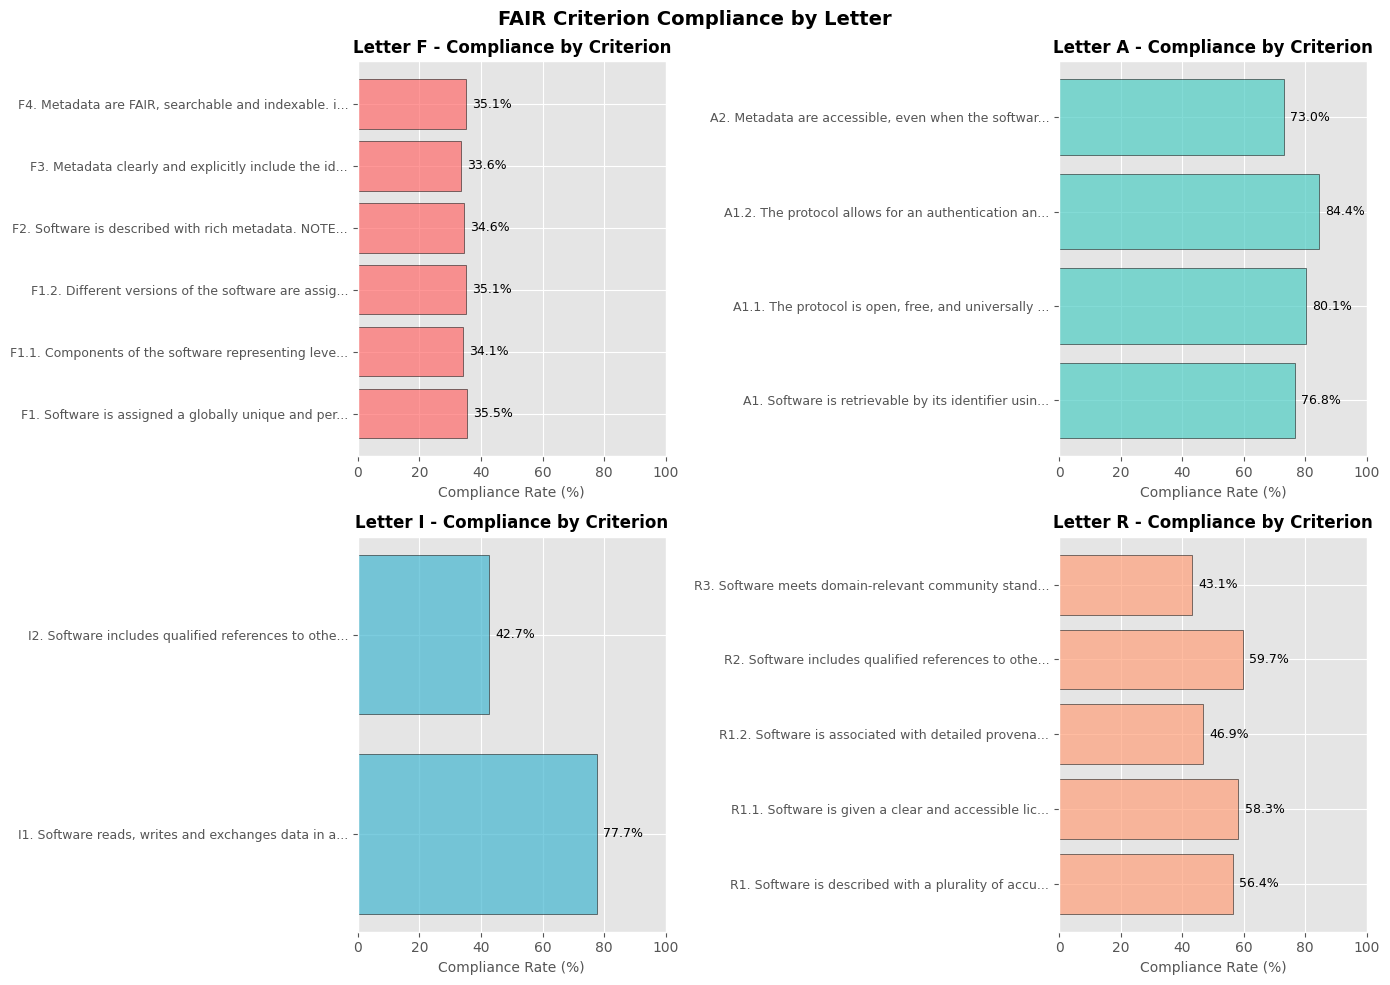

In [2]:
from plotting_scripts.fair_criterion_compliance import plot_fair_criterion_compliance

# Individual Letter Compliance Analysis (Using Letter_compliance)
plot_fair_criterion_compliance(df, F, A, I, R)

Saved plot to graphs\full_fair_compliance_distribution.png


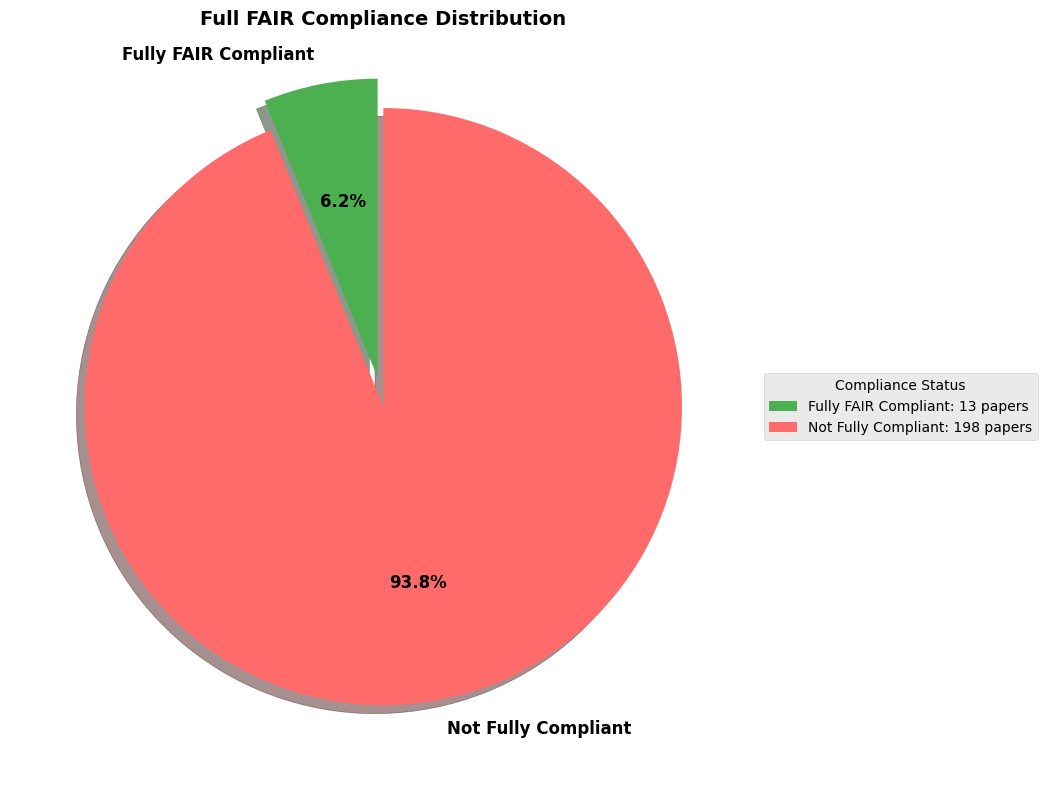

In [3]:
from plotting_scripts.full_fair_compliance import plot_full_fair_compliance

# Full FAIR Compliance Analysis
plot_full_fair_compliance(df)

Saved plot to graphs\distribution_of_fair_criteria_met_per_paper_bar_color_doi_proportion_in_group.png


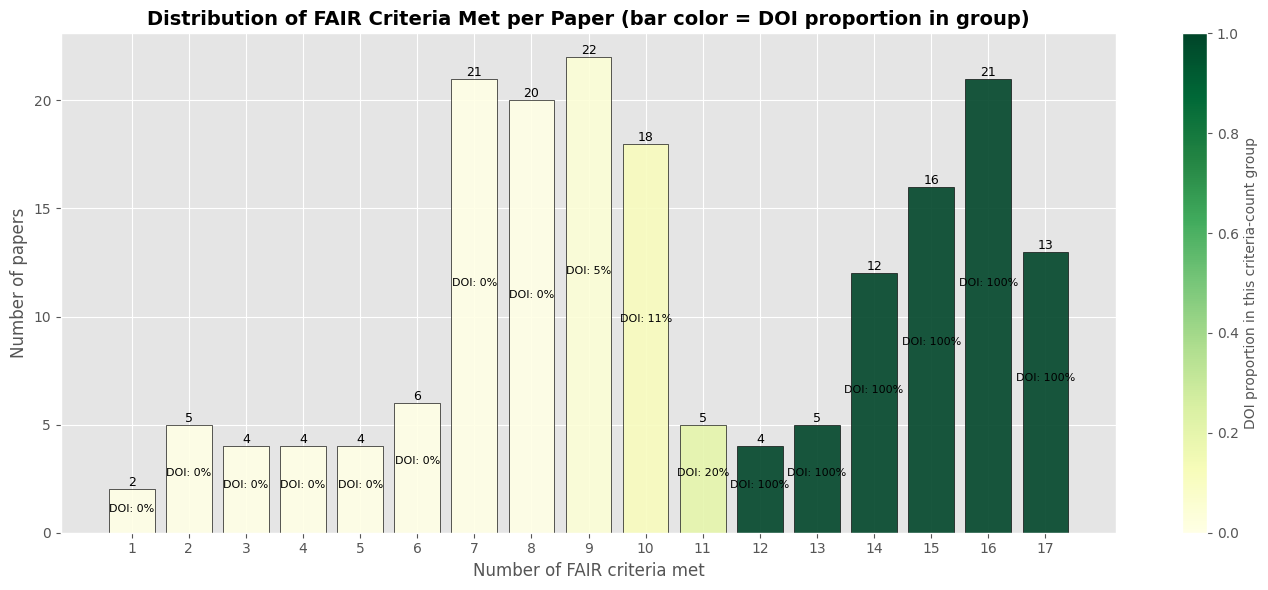

In [4]:
from plotting_scripts.fair_criteria_distribution import plot_fair_criteria_distribution

# Distribution of number of FAIR criteria met (1..n)
# Bar colors indicate DOI proportion within each criteria-count group.
plot_fair_criteria_distribution(df, F, A, I, R)

Saved plot to graphs\artifact_overlap_between_first_and_second_pass.png


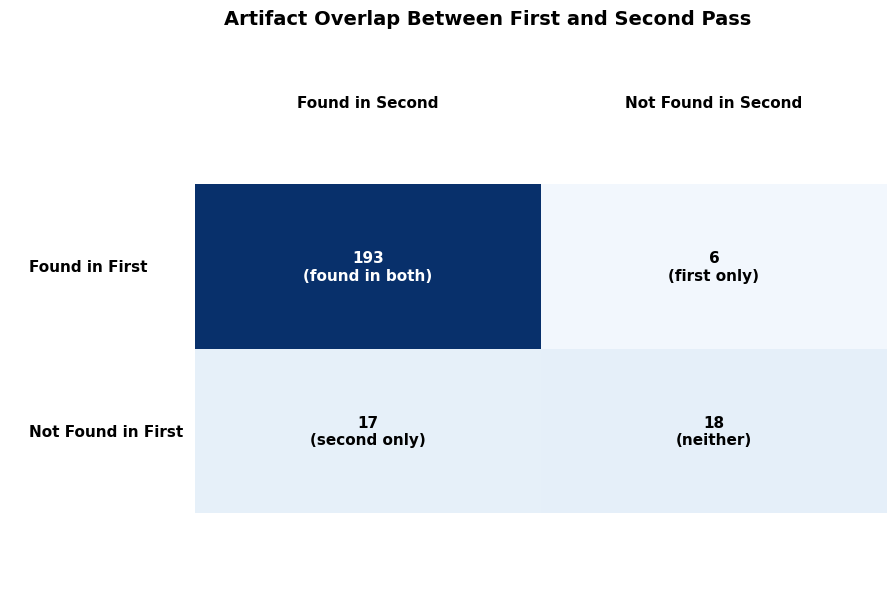

In [5]:
from plotting_scripts.artifact_overlap import plot_artifact_overlap

# Artifact overlap between first and second pass
plot_artifact_overlap()

Saved plot to graphs\acm_badge_compliance_cascade.png


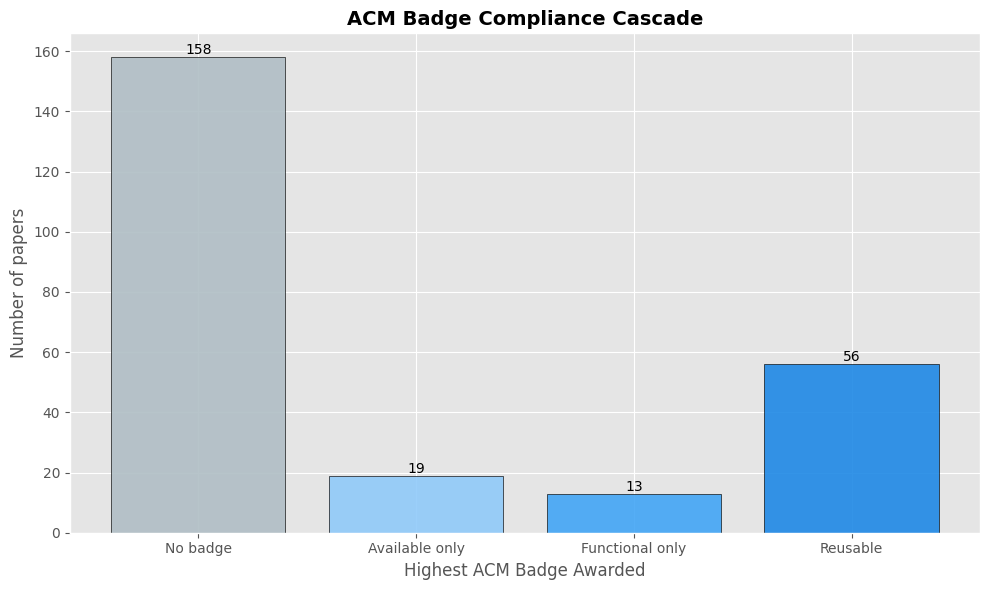

In [6]:
from plotting_scripts.acm_badge_cascade import plot_acm_badge_cascade

# ACM badge compliance cascade (wider criteria)
plot_acm_badge_cascade(sample_file)

First pass (out of available papers): {'Zenodo Only': 27, 'GitHub Only': 95, 'Figshare Only': 8, 'Zenodo and GitHub': 34, 'Figshare and GitHub': 5, 'Anonymous GitHub Only': 6, 'Google Sites': 2, 'Other': 5}
First pass (out of unavailable papers): {'Zenodo Only': 0, 'GitHub Only': 4, 'Figshare Only': 0, 'Zenodo and GitHub': 0, 'Figshare and GitHub': 0, 'Anonymous GitHub Only': 3, 'Google Sites': 0, 'Not Found': 22}
Second pass (out of available papers): {'Zenodo Only': 20, 'GitHub Only': 108, 'Figshare Only': 8, 'Zenodo and GitHub': 30, 'Figshare and GitHub': 5, 'Anonymous GitHub Only': 7, 'Google Sites': 1, 'Other': 5}
Second pass (out of unavailable papers): {'Zenodo Only': 2, 'GitHub Only': 5, 'Figshare Only': 1, 'Zenodo and GitHub': 0, 'Figshare and GitHub': 0, 'Anonymous GitHub Only': 3, 'Google Sites': 0, 'Not Found': 21}


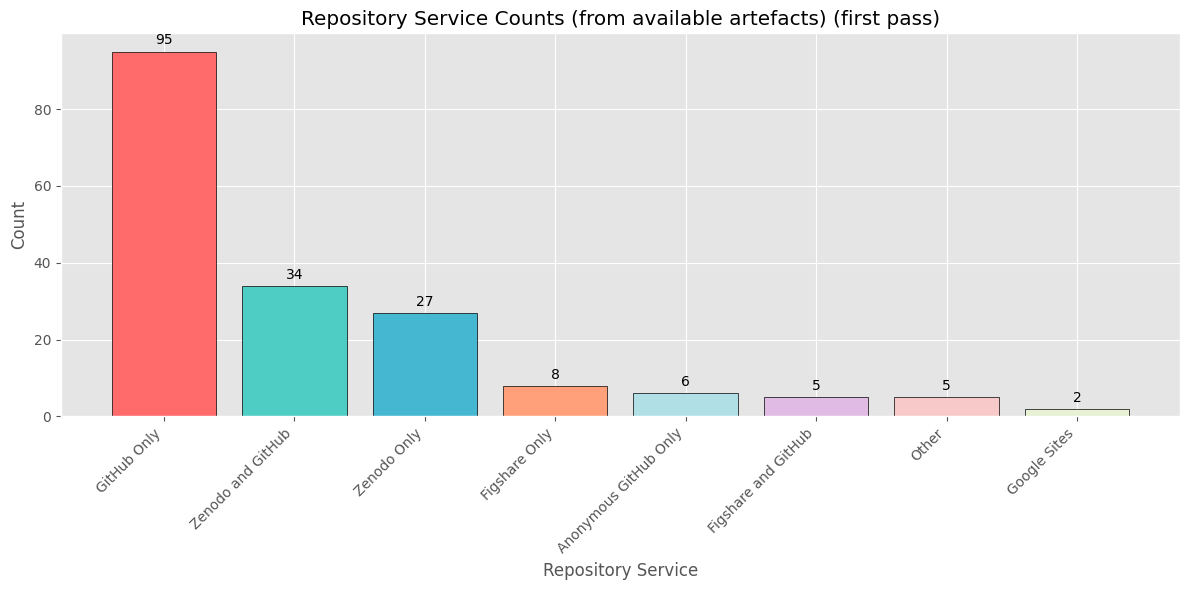

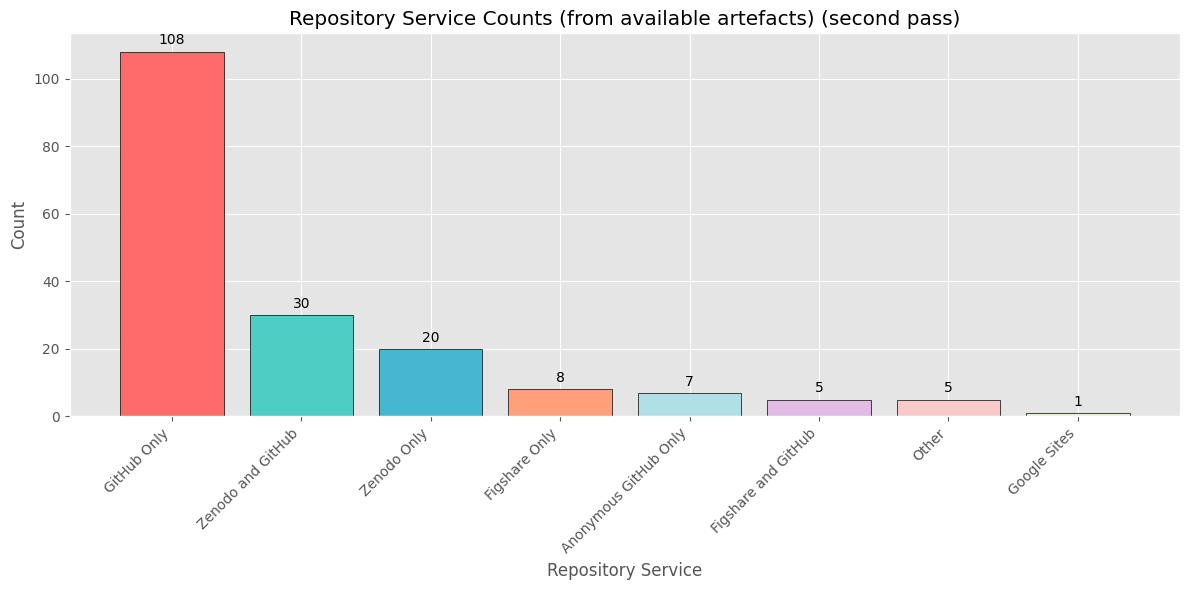

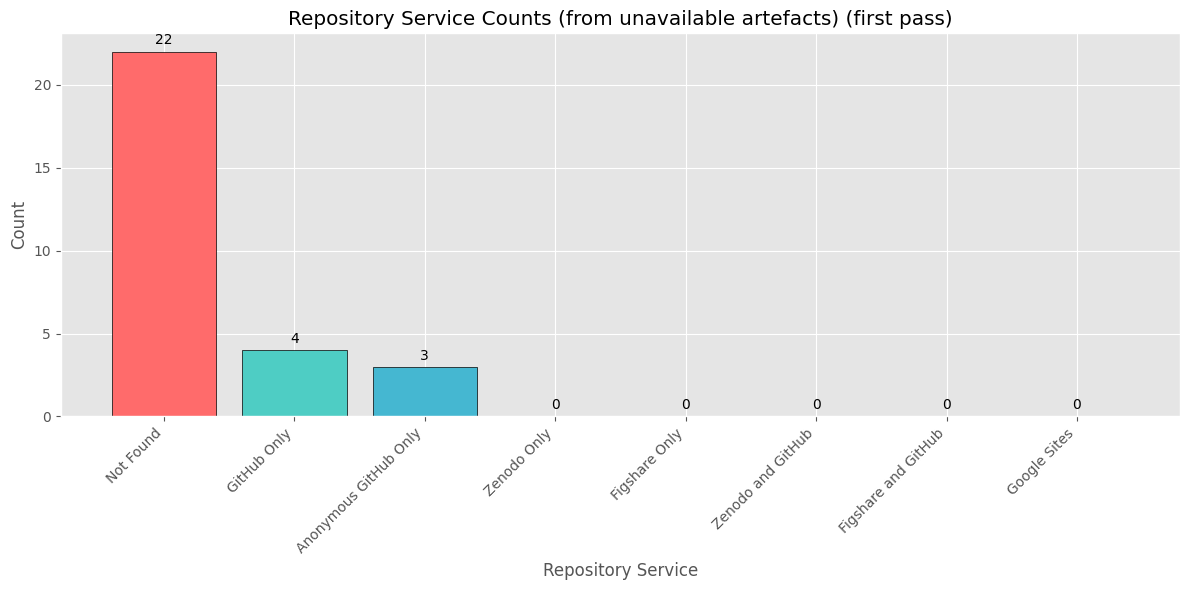

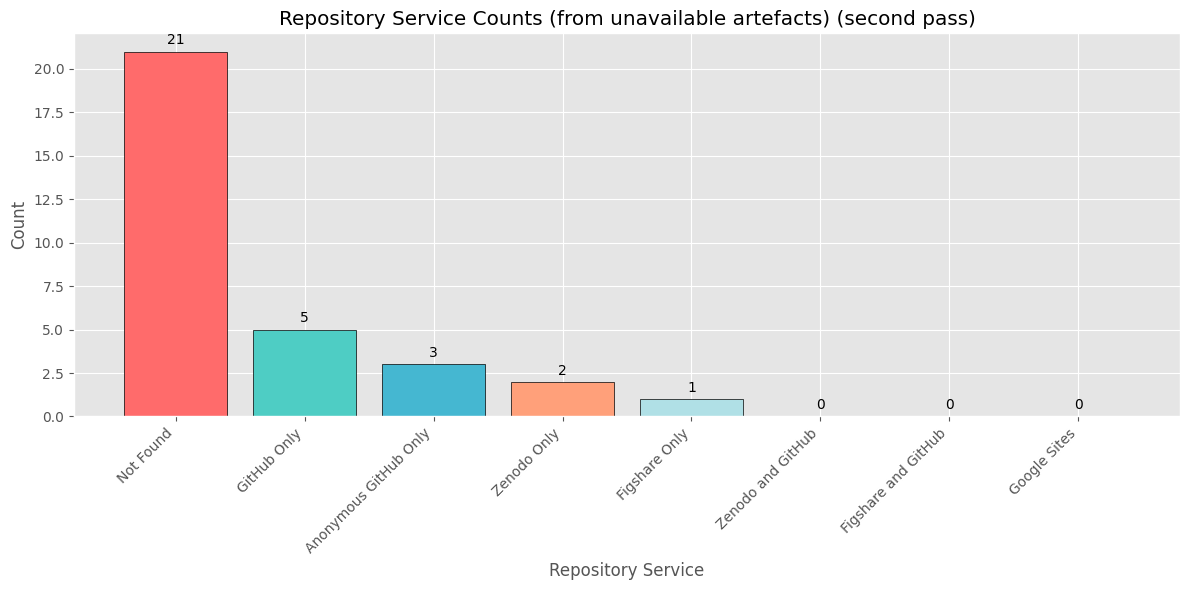

In [7]:
# Repo stats
repo_stats_main()

First pass: {'Available': 182, 'Unavailable': 29, 'No Artefact': 35}
Second pass: {'Available': 184, 'Unavailable': 32, 'No Artefact': 24}


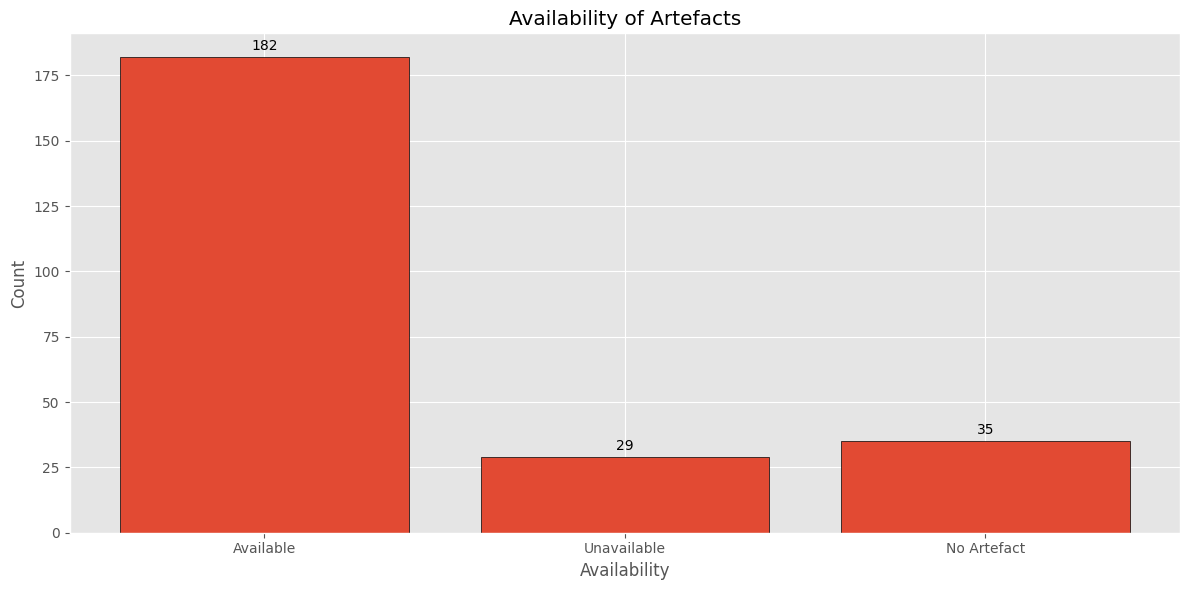

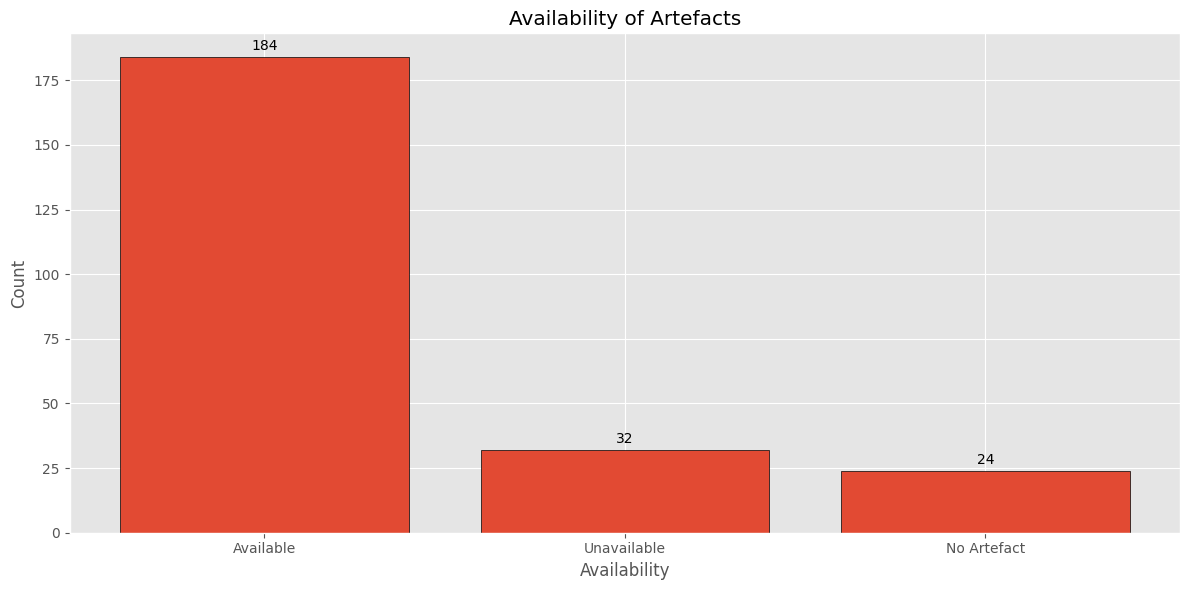

In [8]:
from plotting_scripts.repository_stats import repo_stats_main
from plotting_scripts.artefact_availability import availability_main
availability_main()